# Feature Engineering (Data Preparation and Query)

This query creates the features necessary for a model to analyze the text. It looks at metrics per sentence and the document as a whole, such as average sentence length, burstiness, transition words per sentence, questions per sentence, etc.

In [7]:
import duckdb
import pandas as pd
import numpy as np
import logging

logging.basicConfig(
    level=logging.INFO, 
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

# function to engineer features using DuckDB SQL query
def extract_features():
    con = None
    try:
        logger.info("Connecting to DuckDB in-memory database...")
        con = duckdb.connect(database=':memory:')

        query = """
            SELECT 
                d.Doc_ID,
                CASE WHEN a.Author_Type = 'AI' THEN 1 ELSE 0 END AS Target_Is_AI,
                
                COUNT(t.Chunk_ID) AS Sentence_Count,
                ROUND(AVG(LENGTH(t.Raw_Text)), 2) AS Avg_Sentence_Length,
                ROUND(STDDEV(LENGTH(t.Raw_Text)), 2) AS Burstiness,
                ROUND(MAX(LENGTH(t.Raw_Text)), 2) AS Max_Sentence_Length,
                ROUND(MIN(LENGTH(t.Raw_Text)), 2) AS Min_Sentence_Length,
                
                ROUND(SUM(LENGTH(t.Raw_Text) - LENGTH(REPLACE(t.Raw_Text, ',', ''))) / CAST(COUNT(t.Chunk_ID) AS FLOAT), 3) AS Commas_Per_Sentence,
                
                ROUND(AVG(LENGTH(t.Raw_Text) / (LENGTH(t.Raw_Text) - LENGTH(REPLACE(t.Raw_Text, ' ', '')) + 1)), 2) AS Avg_Word_Length,
                
                ROUND(SUM(LENGTH(t.Raw_Text) - LENGTH(REPLACE(t.Raw_Text, '?', ''))) / CAST(COUNT(t.Chunk_ID) AS FLOAT), 3) AS Questions_Per_Sentence,
                
                ROUND(SUM(LENGTH(t.Raw_Text) - LENGTH(REPLACE(t.Raw_Text, '''', ''))) / CAST(COUNT(t.Chunk_ID) AS FLOAT), 3) AS Contractions_Per_Sentence,
                
                ROUND(SUM(
                    (LENGTH(LOWER(t.Raw_Text)) - LENGTH(REPLACE(LOWER(t.Raw_Text), 'furthermore', ''))) / 11 +
                    (LENGTH(LOWER(t.Raw_Text)) - LENGTH(REPLACE(LOWER(t.Raw_Text), 'moreover', ''))) / 8 +
                    (LENGTH(LOWER(t.Raw_Text)) - LENGTH(REPLACE(LOWER(t.Raw_Text), 'in conclusion', ''))) / 13 +
                    (LENGTH(LOWER(t.Raw_Text)) - LENGTH(REPLACE(LOWER(t.Raw_Text), 'consequently', ''))) / 12 +
                    (LENGTH(LOWER(t.Raw_Text)) - LENGTH(REPLACE(LOWER(t.Raw_Text), 'additionally', ''))) / 12 +
                    (LENGTH(LOWER(t.Raw_Text)) - LENGTH(REPLACE(LOWER(t.Raw_Text), 'however', ''))) / 7 +
                    (LENGTH(LOWER(t.Raw_Text)) - LENGTH(REPLACE(LOWER(t.Raw_Text), 'meanwhile', ''))) / 9 +
                    (LENGTH(LOWER(t.Raw_Text)) - LENGTH(REPLACE(LOWER(t.Raw_Text), 'it is important to note', ''))) / 23
                ) / CAST(COUNT(t.Chunk_ID) AS FLOAT), 4) AS Transitions_Per_Sentence
                
            FROM 'data_organizer/FINAL_1_authors.parquet' a
            JOIN 'data_organizer/FINAL_3_documents.parquet' d ON a.Author_ID = d.Author_ID
            JOIN 'data_organizer/FINAL_4_text_chunks.parquet' t ON d.Doc_ID = t.Doc_ID
            GROUP BY 
                d.Doc_ID, 
                a.Author_Type
            HAVING COUNT(t.Chunk_ID) > 2; 
        """

        logger.info("Executing SQL query. Reading parquet files and calculating features...")
        ml_df = con.execute(query).df()
        
        logger.info(f"Query successful. Extracted {len(ml_df):,} rows.")

        # Check for NaNs before blindly filling them
        null_count = ml_df.isna().sum().sum()
        if null_count > 0:
            logger.warning(f"Found {null_count} missing values (likely NaN from STDDEV on small chunks). Imputing with 0.")
            ml_df.fillna(0, inplace=True)
        else:
            logger.info("No missing values detected.")

        return ml_df

    # Catch Specific Errors
    except duckdb.Error as e:
        logger.error(f"DuckDB SQL Error: Check your syntax or file paths. Details: {e}")
    except Exception as e:
        logger.error(f"An unexpected Python error occurred: {e}")
        
    # The Cleanup Phase
    finally:
        if con:
            con.close()
            logger.info("DuckDB connection securely closed.")

# Run the function and display results
ml_df = extract_features()

if ml_df is not None:
    display(ml_df.head())

2026-03-30 16:03:04 - INFO - Connecting to DuckDB in-memory database...
2026-03-30 16:03:04 - INFO - Executing SQL query. Reading parquet files and calculating features...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-03-30 16:03:13 - INFO - Query successful. Extracted 96,007 rows.
2026-03-30 16:03:13 - INFO - No missing values detected.
2026-03-30 16:03:13 - INFO - DuckDB connection securely closed.


,Doc_ID,Target_Is_AI,Sentence_Count,Avg_Sentence_Length,Burstiness,Max_Sentence_Length,Min_Sentence_Length,Commas_Per_Sentence,Avg_Word_Length,Questions_Per_Sentence,Contractions_Per_Sentence,Transitions_Per_Sentence
0,a4e43de8-f5dd-484d-9ee0-9f54e50c3fa9,1,18,135.72,35.16,214,77,1.056,5.87,0.056,0.000,0.2778
1,fbaaa7b3-59ca-41a9-a0fe-f513288f4d35,1,19,126.74,30.34,167,50,0.684,5.69,0.000,0.000,0.1053
2,d4b6c9da-8a54-4181-85ad-965dced74ef0,1,19,106.95,46.02,178,16,0.632,5.67,0.000,0.053,0.0000
3,eee4bfe0-9aeb-4780-a012-0bed6b489f42,1,16,143.19,50.04,237,43,1.313,5.86,0.000,0.063,0.0000
4,075decbe-83bd-406a-b0f6-1d903b1a4229,1,15,151.00,46.81,260,80,1.267,6.03,0.000,0.000,0.0667


# EDA

In [10]:
import pandas as pd
import logging

logging.basicConfig(
    level=logging.INFO, 
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

#function to run eda on new features
def run_exploratory_data_analysis(df):
    try:
        logger.info("Starting Exploratory Data Analysis...")
        
        if df is None or df.empty:
            logger.error("The dataframe is empty or None. SQL extraction may have failed.")
            return

        if 'Target_Is_AI' not in df.columns:
            logger.error("Missing required column: 'Target_Is_AI'. Check the SQL query.")
            return
            
        df['Author_Label'] = df['Target_Is_AI'].map({1: 'AI', 0: 'Human'})

        total_rows = len(df)
        logger.info(f"Successfully loaded {total_rows:,} documents for analysis.")

        distribution = df['Author_Label'].value_counts()
        print("\n--- Class Distribution ---")
        print(distribution.to_string())

        # Define expected features
        feature_columns = [
            'Sentence_Count', 
            'Avg_Sentence_Length', 
            'Burstiness', 
            'Max_Sentence_Length', 
            'Min_Sentence_Length',
            'Commas_Per_Sentence',          
            'Questions_Per_Sentence',       
            'Avg_Word_Length',
            'Contractions_Per_Sentence',
            'Transitions_Per_Sentence'
        ]

        # Check for missing feature columns before analysis
        missing_cols = [col for col in feature_columns if col not in df.columns]
        if missing_cols:
            logger.warning(f"Missing features detected. Skipping: {missing_cols}")
            feature_columns = [col for col in feature_columns if col in df.columns]

        if feature_columns:
            averages = df.groupby('Author_Label')[feature_columns].mean().round(2).T
            print("\n--- Average Metrics by Author Type ---")
            print(averages.to_string())
        else:
            logger.error("No valid feature columns found to calculate averages.")

        logger.info("EDA completed successfully.")

    except KeyError as e:
        logger.error(f"A column was missing during Pandas operations. Details: {e}")
    except Exception as e:
        logger.error(f"An unexpected Python error occurred during EDA: {e}")

run_exploratory_data_analysis(ml_df)

2026-03-30 16:33:26 - INFO - Starting Exploratory Data Analysis...
2026-03-30 16:33:26 - INFO - Successfully loaded 96,007 documents for analysis.
2026-03-30 16:33:26 - INFO - EDA completed successfully.



--- Class Distribution ---
Author_Label
AI       51967
Human    44040

--- Average Metrics by Author Type ---
Author_Label                   AI   Human
Sentence_Count              15.66   16.41
Avg_Sentence_Length        151.94  134.53
Burstiness                  60.84   58.46
Max_Sentence_Length        265.13  252.19
Min_Sentence_Length         75.35   57.21
Commas_Per_Sentence          1.03    0.87
Questions_Per_Sentence       0.01    0.02
Avg_Word_Length              6.50    6.08
Contractions_Per_Sentence    0.15    0.15
Transitions_Per_Sentence     0.10    0.03


In our initial pre-model analysis, it appears that there is a fairly equal distribution in documents by source. Additionally, AI written documents seem to have a much longer average sentence length as compared to humans. Contrary to prior belief, there doesn't seem to be much difference in feature burstiness between the two sources, with humans actually having less burstiness than the AI models. This could be unique to academic writing. Other features provide some up front differences, such as the use of transition words, questions asked, minimum sentence length, and commas used.

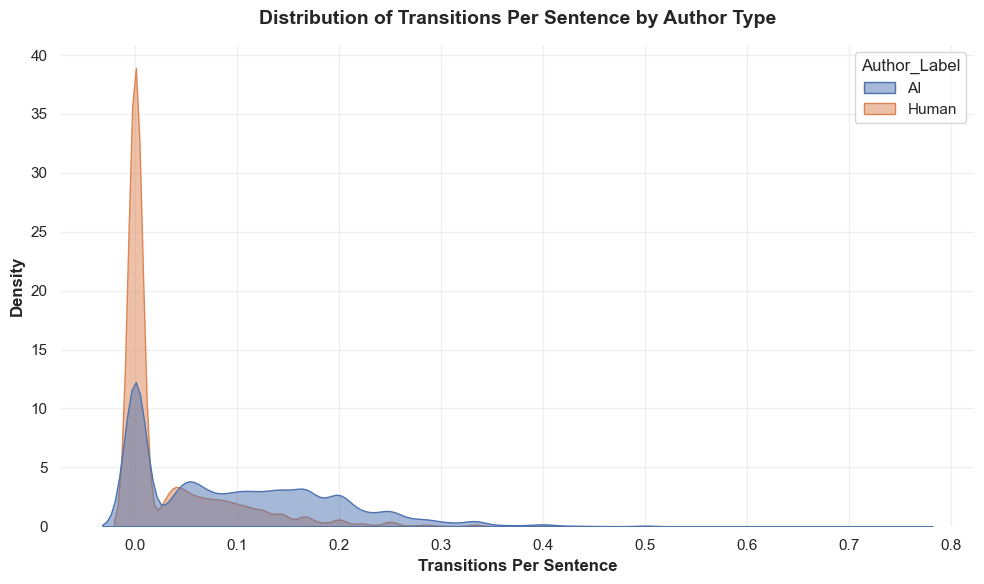

2026-03-30 16:33:31 - INFO - Distribution plot generated successfully.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import logging

logging.basicConfig(
    level=logging.INFO, 
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

def plot_transitions_distribution(df):
    try:
        if df is None or df.empty:
            logger.error("The dataframe is empty or None. Cannot plot distribution.")
            return

        if 'Transitions_Per_Sentence' not in df.columns or 'Author_Label' not in df.columns:
            logger.error("Required columns for plotting are missing. Run your EDA block first to generate 'Author_Label'.")
            return

        plt.figure(figsize=(10, 6))
        
        sns.kdeplot(
            data=df, 
            x='Transitions_Per_Sentence', 
            hue='Author_Label', 
            fill=True, 
            common_norm=False, 
            alpha=0.5
        )
        
        plt.title('Distribution of Transitions Per Sentence by Author Type', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel('Transitions Per Sentence', fontsize=12, fontweight='bold')
        plt.ylabel('Density', fontsize=12, fontweight='bold')
        
        sns.despine(left=True, bottom=True)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        logger.info("Distribution plot generated successfully.")
        
    except KeyError as e:
        logger.error(f"A column was missing during plotting. Details: {e}")
    except Exception as e:
        logger.error(f"An unexpected Python error occurred during plotting: {e}")

plot_transitions_distribution(ml_df)

# Solution Analysis

In [4]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import logging

logging.basicConfig(
    level=logging.INFO, 
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

#train an XGBoost classifier to predict ai/human writing
def train_xgboost_classifier(df):
    try:
        logger.info("Starting XGBoost Modeling Pipeline...")
        
        if df is None or df.empty:
            logger.error("Dataframe is empty. Cannot train model.")
            return None
        
        #engineered features
        feature_cols = [
            'Sentence_Count', 
            'Avg_Sentence_Length', 
            'Burstiness', 
            'Max_Sentence_Length', 
            'Min_Sentence_Length',
            'Commas_Per_Sentence',          
            'Questions_Per_Sentence',       
            'Avg_Word_Length',
            'Contractions_Per_Sentence',
            'Transitions_Per_Sentence'
        ]
        
        missing_cols = [col for col in feature_cols + ['Target_Is_AI'] if col not in df.columns]
        if missing_cols:
            logger.error(f"Missing critical columns for modeling: {missing_cols}")
            return None

        logger.info("Separating features (X) and target label (y)...")
        X = df[feature_cols]
        y = df['Target_Is_AI']

        logger.info("Splitting data into 80% Training and 20% Testing sets...")
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        logger.info(f"Training on {len(X_train):,} documents, Testing on {len(X_test):,} documents.")

        #  Initialize the XGBoost Classifier
        logger.info("Initializing XGBoost algorithm...")
        xgb_model = xgb.XGBClassifier(
            n_estimators=150,       
            learning_rate=0.1,     
            max_depth=6,           
            random_state=42,      
            eval_metric='logloss'   
        )

        # Train the Model
        logger.info("Fitting the model (this may take a few seconds)...")
        xgb_model.fit(X_train, y_train)
        logger.info("Model training successfully completed.")

        # Predict and Evaluate
        logger.info("Generating predictions on the holdout test set...")
        y_pred = xgb_model.predict(X_test)
        
        # Calculate and print the final metrics
        acc = accuracy_score(y_test, y_pred)
        logger.info(f"Model Evaluation Complete. Final Accuracy: {acc:.4f}")
        
        print(f"\n==========================================")
        print(f" XGBOOST MODEL ACCURACY: {acc:.4f}")
        print(f"==========================================\n")
        print("--- Classification Report ---")
        print(classification_report(y_test, y_pred, target_names=['Human (0)', 'AI (1)']))
        
        return xgb_model, feature_cols

    # Error Catching
    except ValueError as e:
        logger.error(f"Data formatting error (e.g., text found where numbers were expected): {e}")
    except Exception as e:
        logger.error(f"An unexpected error occurred during model training: {e}")
        return None, None
trained_model, final_features = train_xgboost_classifier(ml_df)

2026-03-30 15:48:37 - INFO - Starting XGBoost Modeling Pipeline...
2026-03-30 15:48:37 - INFO - Separating features (X) and target label (y)...
2026-03-30 15:48:37 - INFO - Splitting data into 80% Training and 20% Testing sets...
2026-03-30 15:48:37 - INFO - Training on 76,805 documents, Testing on 19,202 documents.
2026-03-30 15:48:37 - INFO - Initializing XGBoost algorithm...
2026-03-30 15:48:37 - INFO - Fitting the model (this may take a few seconds)...
2026-03-30 15:48:38 - INFO - Model training successfully completed.
2026-03-30 15:48:38 - INFO - Generating predictions on the holdout test set...
2026-03-30 15:48:38 - INFO - Model Evaluation Complete. Final Accuracy: 0.8996



 XGBOOST MODEL ACCURACY: 0.8996

--- Classification Report ---
              precision    recall  f1-score   support

   Human (0)       0.89      0.90      0.89      8850
      AI (1)       0.91      0.90      0.91     10352

    accuracy                           0.90     19202
   macro avg       0.90      0.90      0.90     19202
weighted avg       0.90      0.90      0.90     19202



# Analysis Rationale

I chose the XGBoost model due to its ability to classify using a tree structure, its gradient boosting algorithm, and the overall complexity of the model. I trained it on the features I previously engineered and achieved an accuracy of 0.90, meaning the model could predict 9 out of 10 documents correctly whether it is AI or Human. This model uses logloss as its learning metric, which is industry standard for binary classification.

# Visualize Results

2026-03-30 15:48:50 - INFO - Starting visualization: XGBoost Feature Importance...
2026-03-30 15:48:50 - INFO - Extracting information gain metrics from the model...
2026-03-30 15:48:50 - INFO - Formatting the plot for publication quality...
2026-03-30 15:48:50 - INFO - Rendering Feature Importance plot successfully.


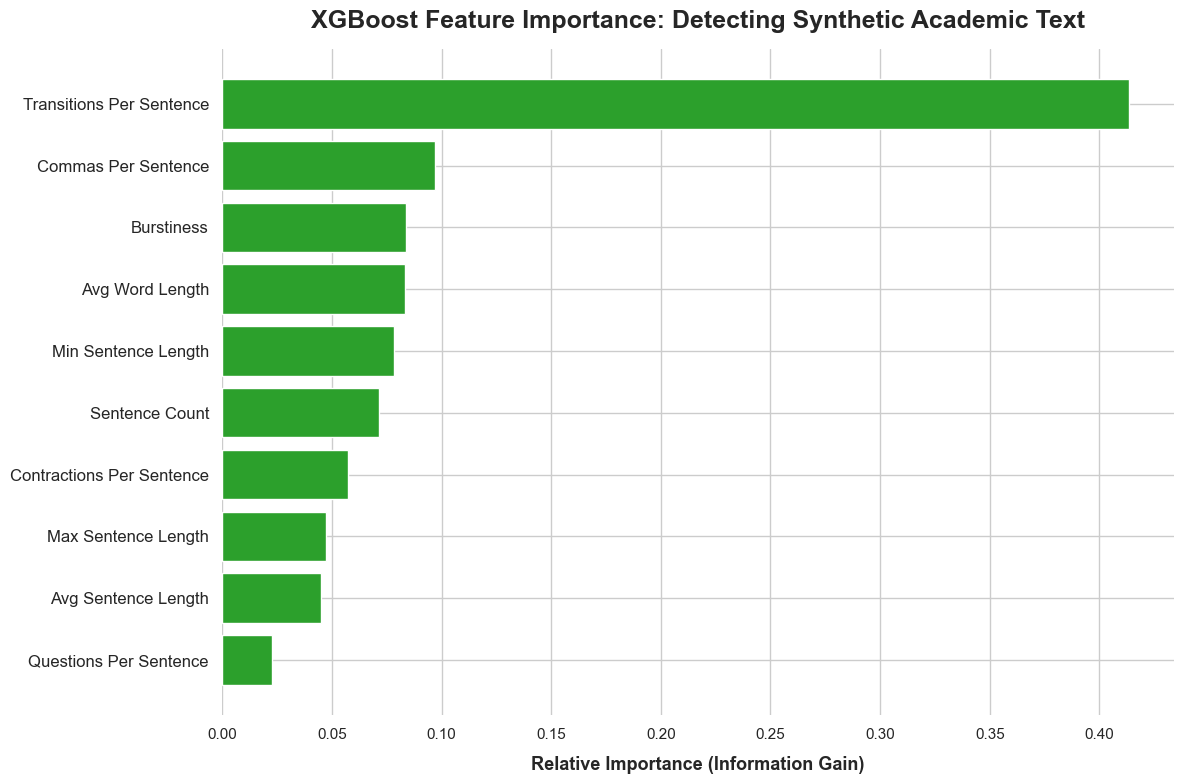

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

logger = logging.getLogger(__name__)

# Function to plot feature importance from the trained XGBoost model
def plot_feature_importance(model, feature_names):
    try:
        logger.info("Starting visualization: XGBoost Feature Importance...")

        if model is None:
            logger.error("No trained model provided. Did the XGBoost training cell fail?")
            return
        if not feature_names or len(feature_names) == 0:
            logger.error("No feature names provided to map to the importances.")
            return

        logger.info("Extracting information gain metrics from the model...")
        importances = model.feature_importances_
        
        # Verify the number of features matches the number of importances
        if len(importances) != len(feature_names):
            logger.error("Mismatch: Number of model importances does not match number of feature names.")
            return

        indices = np.argsort(importances)

        logger.info("Formatting the plot for publication quality...")
        plt.figure(figsize=(12, 8)) 
        sns.set_theme(style="whitegrid")

        plt.barh(range(len(indices)), importances[indices], color='#2ca02c', align='center')

        
        clean_features = [feature_names[i].replace('Feature_', '').replace('_', ' ') for i in indices]
        
        plt.yticks(range(len(indices)), clean_features, fontsize=12)
        plt.xlabel('Relative Importance (Information Gain)', fontsize=13, fontweight='bold', labelpad=10)
        plt.title('XGBoost Feature Importance: Detecting Synthetic Academic Text', fontsize=18, fontweight='bold', pad=15)

        sns.despine(left=True, bottom=True)
        plt.tight_layout()

        logger.info("Rendering Feature Importance plot successfully.")
        plt.show()

    except AttributeError as e:
        logger.error(f"The provided model does not support feature importances. Details: {e}")
        plt.close()
    except Exception as e:
        logger.error(f"An unexpected error occurred during plotting: {e}")
        plt.close() 


plot_feature_importance(trained_model, final_features)

Figure 1. Feature Importance of XGBoost

# Visualization Rationale

To effectively communicate how the XGBoost model differentiates between human and synthetic academic text, I designed a feature importance visualization optimized for interpretability to answer my original question - what features distinguish AI and human generated academic writing from each other? The features were mathematically sorted by their Information Gain (np.argsort) and plotted so that the most heavily weighted feature (Transitions Per Sentence) sits at the absolute top. A feature importance bar chart was most ideal to communicate my findings due to its simplicity, but its straightforwardness to present the top features that the model used to make its prediction.